# Report on MPW3 – Image Captioning (IC)
<div class="alert alert-block alert-warning">
This is a <b>report NB</b> for submission together with PDF file. Original <code>captioning_starter.ipynb</code> file was used as a template, but many markdown cells are shorten or removed for easier navigation.
</div>


# Image Captioning on the Flicker8k Dataset


##  Team Name and Members
* Team Name: **demidova_keller** (used in submitted file names)
* Student 1: Iuliia Demidova (iuliia.demidova@students.fhnw.ch)
* Student 2: Lucas Keller (lucas.keller@students.fhnw.ch)


## 1 Project Setup


### 1.1 Create the virtual environment

In [1]:
# imports
import textwrap

import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision

from dataloader import (
    build_tokenizer_from_split,
    create_caption_dataloader
)
from tokenizer import tokenize

print("torch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)

# TODO: Add your own imports here, if needed.
import textwrap

torch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128


Output:

`torch version: 2.10.0`

`torchvision version: 0.25.0`

### 1.2 Download the dataset
* The Flickr8k dataset used in this challenge is available under [Flickr 8k Dataset - Kaggle](https://www.kaggle.com/datasets/adityajn105/flickr8k).
* Captions, splits, and images are included in the `../notebooks/data/` directory. The data directory has this structure:

<img src="data_structure.png"/>

## 2 Data loader and Tokenizer
### 2.1 Data loader
The repository includes:
 * `Dataset`-class: `Flickr8kCaptionsDatasetBase`
  * `DataLoader`'s

that are based on this specific structure of the data directory.

You can use `create_caption_dataloader` for obtaining instances for the train and test data loaders.

### 2.2 Tokenizer
You can configure it with the `tokenizer` provided in the repo.

The `tokenizer` performs some **preprocessing** steps of the captions. It also **creates a vocabulary** from the training data and then provides **a mapping from the words to tokens**.

Note that there are also some special tokens introduced that are important when processing the captions during training or generating the captions during inference:

| Word    | ID | Role                                                                                                           |
|---------|----|----------------------------------------------------------------------------------------------------------------|
| `<pad>` | 0  | **padding** for filling up sequence to a given length in a mini-batch.                                         |
| `<bos>` | 1  | **beginning of sentence** - each tokenized sentence should start with `<bos>`, i.e. also the generated ones.   |
| `<eos>` | 2  | **end of sentence** - for fixed length captions will signal that the rest will consist of `<pad>`-tokens only. |
| `<unk>` | 3  | **unknown - not available in vocabulary**                                                                      |

### 2.3 Data preprocessing and Augmentation
* Furthermore, specify your transforms used for **preprocessing and augmenting the images** and pass them to the `create_caption_dataloader`-method.
* The mini-batches created by the dataloader have the following structure:
    * `(images, captions, lengths, image_ids, raw_captions)`.


* **Captions are built from the training vocabulary only**, and `lengths` may let you mask padding tokens in the loss.


In [2]:
# Transforms
from torchvision import transforms

IMAGENET_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def _convert_to_rgb(image: Image.Image) -> Image.Image:
    return image.convert("RGB")

def build_train_transforms() -> transforms.Compose:
    return transforms.Compose([
            transforms.Lambda(_convert_to_rgb),

            # Mild augmentation:
            # - keeps ImageNet-compatible 224x224 input size for ResNet
            # - avoids aggressive crops that could remove caption-relevant objects
            # - horizontal flip is safe, based on the images content
            # - small color jitter improves robustness
            transforms.RandomResizedCrop(
                size=IMAGENET_SIZE,
                scale=(0.85, 1.0),
                ratio=(0.9, 1.1),
            ),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(
                brightness=0.15,
                contrast=0.15,
                saturation=0.10,
                hue=0.02,
            ),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)])

def build_test_transforms() -> transforms.Compose:
    return transforms.Compose([
            transforms.Lambda(_convert_to_rgb),
            transforms.Resize((IMAGENET_SIZE,IMAGENET_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)])

def denormalize_image(image: torch.Tensor) -> torch.Tensor:
    """Undo ImageNet normalization for visualization."""
    mean_tensor = image.new_tensor(IMAGENET_MEAN).view(-1, 1, 1)
    std_tensor = image.new_tensor(IMAGENET_STD).view(-1, 1, 1)
    return (image * std_tensor + mean_tensor).clamp(0, 1)

In [3]:
# TODO: ADJUST PATH TO data_dir IF NEEDED
data_dir = "data/"
# TODO: SET REASONABLE VALUES FOR THE FOLLOWING PARAMETERS
# Tokenizer / dataloader parameters
# Flickr8k is small, so we filter out rare words to reduce vocabulary noise,
#   keep captions long enough to avoid cutting normal sentences,
#   and use a batch size that is okay for CPU/MPS

MIN_WORD_FREQ = 5   # Keep words appearing at least 5 times in train captions
MAX_LEN = 40        # Max caption length including <bos>/<eos>, longer captions are cut
BATCH_SIZE = 32     # Kind of default value

In [5]:
# Vocabulary is built ONLY from training captions to avoid test leakage.
tokenizer = build_tokenizer_from_split(
    split="train",
    data_dir=data_dir,
    min_freq=MIN_WORD_FREQ,
)

# To test the provided tokenizer:
assert tokenizer.stoi["<pad>"] == 0
assert tokenizer.stoi["<bos>"] == 1
assert tokenizer.stoi["<eos>"] == 2
assert tokenizer.stoi["<unk>"] == 3

PAD_IDX = tokenizer.stoi["<pad>"]
BOS_IDX = tokenizer.stoi["<bos>"]
EOS_IDX = tokenizer.stoi["<eos>"]
UNK_IDX = tokenizer.stoi["<unk>"]

# Loaders
train_loader = create_caption_dataloader(
    split="train",
    data_dir=data_dir,
    tokenizer=tokenizer,
    transform=build_train_transforms(),
    batch_size=BATCH_SIZE,
    max_len=MAX_LEN,
    caption_sampling="all", # To use all train captions, as one image <-> several captions in captions.txt
)

test_loader = create_caption_dataloader(
    split="test",
    data_dir=data_dir,
    tokenizer=tokenizer,
    transform=build_test_transforms(),
    batch_size=BATCH_SIZE,
    max_len=MAX_LEN,
    caption_sampling="all", # To use all train captions, as one image <-> several captions in captions.txt
)

# Image-level test loader
#   For generation/qualitative examples: each image appears once.
test_image_loader = create_caption_dataloader(
    split="test",
    data_dir=data_dir,
    tokenizer=tokenizer,
    transform=build_test_transforms(),
    batch_size=BATCH_SIZE,
    max_len=MAX_LEN,
    caption_sampling="first", # Take only 1st caption
)

# Inspecting training batch
images, captions, lengths, image_ids, raw_captions = next(iter(train_loader))

print(f"Vocabulary size: {len(tokenizer):,}")
print(f"Special token IDs: pad={PAD_IDX}, bos={BOS_IDX}, eos={EOS_IDX}, unk={UNK_IDX}")
print("\nTRAIN BATCH")
print(f"Number of training caption examples: {len(train_loader.dataset):,}")
print(f"Train batch image tensor shape: {tuple(images.shape)}")
print(f"Train batch caption tensor shape: {tuple(captions.shape)}")
print(f"Train caption lengths in first batch: {lengths.tolist()}")

FileNotFoundError: [Errno 2] No such file or directory: 'data\\images\\747242766_afdc9cb2ba.jpg'

In [14]:
# Inspecting test batch
images, captions, lengths, image_ids, raw_captions = next(iter(test_loader))
print("TEST BATCH")
print(f"Number of test caption examples: {len(test_loader.dataset):,}")
print(f"Test batch image tensor shape: {tuple(images.shape)}")
print(f"Test batch caption tensor shape: {tuple(captions.shape)}")
print(f"Test caption lengths in first batch: {lengths.tolist()}")

TEST BATCH
Number of test caption examples: 8,090
Test batch image tensor shape: (32, 3, 224, 224)
Test batch caption tensor shape: (32, 40)
Test caption lengths in first batch: [14, 21, 9, 21, 21, 15, 20, 11, 19, 18, 12, 18, 9, 13, 7, 17, 17, 20, 14, 21, 12, 12, 12, 8, 11, 15, 10, 18, 11, 19, 13, 10]


In [15]:
# Inspecting image-level test batch
images, captions, lengths, image_ids, raw_captions = next(iter(test_image_loader))
print("IMAGE-LEVEL TEST BATCH")
print(f"Number of unique-ish test image examples for generation: {len(test_image_loader.dataset):,}")
print(f"Generation batch image tensor shape: {tuple(images.shape)}")
print(f"Generation batch caption tensor shape: {tuple(captions.shape)}")

IMAGE-LEVEL TEST BATCH
Number of unique-ish test image examples for generation: 1,618
Generation batch image tensor shape: (32, 3, 224, 224)
Generation batch caption tensor shape: (32, 40)


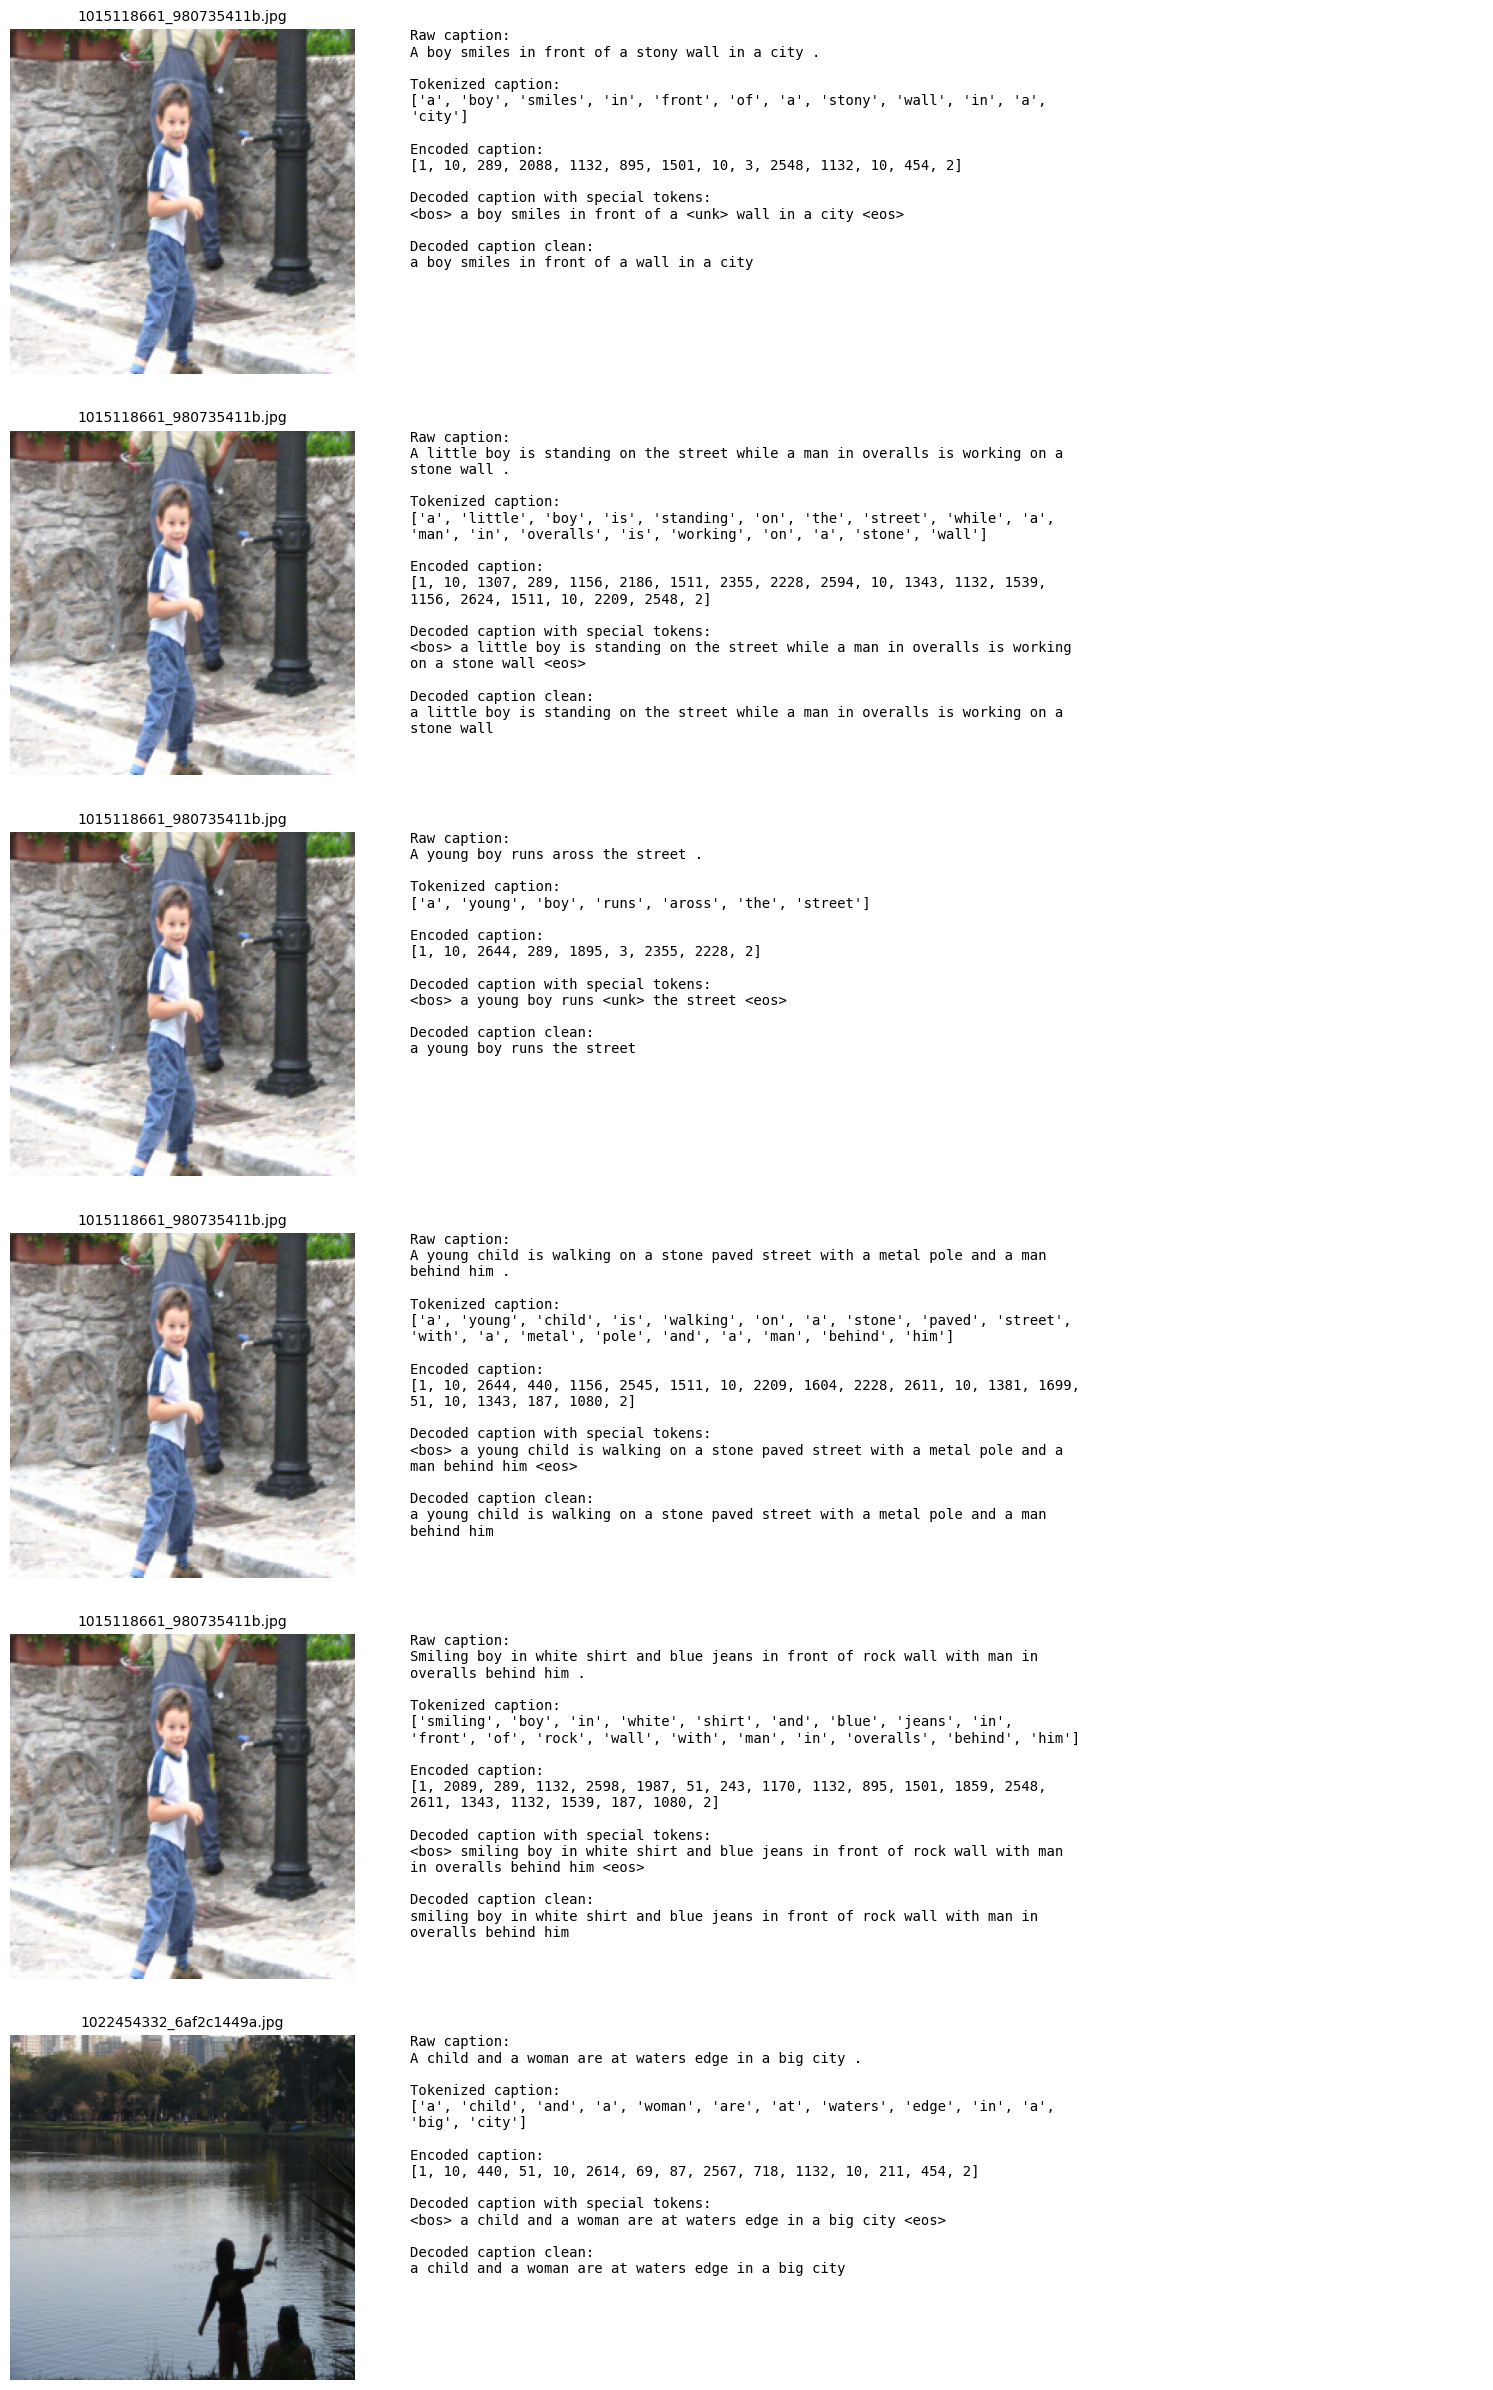

In [24]:
# Grid: images + captions + tokens

# Choosing which loader to inspect:
#   train_loader shows augmented train samples
#   test_loader shows original test samples
viz_loader = test_loader

images, captions, lengths, image_ids, raw_captions = next(iter(viz_loader))

num_examples = 6
n = min(num_examples, len(images))

fig, axes = plt.subplots(
    nrows=n,
    ncols=2,
    figsize=(16, 4 * n),
    gridspec_kw={"width_ratios": [1.1, 2.2]},
    squeeze=False,
)

for idx in range(n):
    image = (
        denormalize_image(images[idx].detach().cpu())
        .permute(1, 2, 0)
        .numpy() # display numpy instead of tensor
    )

    caption_len = int(lengths[idx])
    encoded_caption = captions[idx, :caption_len].tolist()
    tokenized_caption = tokenize(raw_captions[idx])
    decoded_caption_with_specials = tokenizer.decode(
        encoded_caption,
        skip_special_tokens=False,
    )
    decoded_caption_clean = tokenizer.decode(
        encoded_caption,
        skip_special_tokens=True,
    )

    ax_image, ax_text = axes[idx]

    ax_image.imshow(image)
    ax_image.set_title(image_ids[idx], fontsize=10)
    ax_image.axis("off")

    caption_details = "\n\n".join(
        [
            f"Raw caption:\n{textwrap.fill(raw_captions[idx], width=80)}",
            f"Tokenized caption:\n{textwrap.fill(str(tokenized_caption), width=80)}",
            f"Encoded caption:\n{textwrap.fill(str(encoded_caption), width=80)}",
            f"Decoded caption with special tokens:\n{textwrap.fill(decoded_caption_with_specials, width=80)}",
            f"Decoded caption clean:\n{textwrap.fill(decoded_caption_clean, width=80)}",
        ]
    )

    ax_text.axis("off")
    ax_text.text(
        0,
        1,
        caption_details,
        va="top",
        ha="left",
        fontsize=10,
        family="monospace",
    )

plt.tight_layout()
plt.show()

## Shared Utilities

Use this section for shared config and helper functions reused across all experiments. For example define a common training loop, BLEU computation or visualization helpers here. This way your model models stay directly comparable.


In [10]:
# Define shared config, helper functions, a fixed evaluation subset, and BLEU computation.
DEVICE = None
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else: 
    DEVICE = torch.device("cpu")

print("device:", DEVICE)


# further helper functionality:
# ...

device: mps


Two devices used:
* Lucas Keller: `device: cuda` (Nvidia GTX 5070ti)
* Iuliia Demidova: `device: mps`

## Model 1 - Show and Tell

Implement the model described in the [_Show and Tell_](https://arxiv.org/abs/1411.4555) paper . Record the training behavior, inspect a few generated captions on held-out images, and report BLEU on your fixed evaluation subset.

In [ ]:
# TODO Parameters for the Show and Tell architecture  
ENCODER_DIM = 
EMBED_DIM = 
DECODER_DIM = 
DROPOUT = 
FREEZE_ENCODER = 

In [ ]:
# TODO Implement the Show and Tell model classes and any model-specific setup here.

class ShowAndTellEncoder(nn.Module)
    def __init__(self,...):
        # TODO

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        # TODO


class ShowAndTellCaptioner(nn.Module):
    def __init__(self,...):
        # TODO
    def forward(self, images: torch.Tensor, captions: torch.Tensor) -> torch.Tensor:
        # TODO    
    @torch.no_grad()
    def generate(self, images: torch.Tensor, max_len=35) -> torch.Tensor:
        # TODO

In [ ]:
# TODO: Add the training loop, caption generation, evaluation and metric calculation logic for Model 1 here and in the following cells.

Briefly summarize what happened during training, which captions looked convincing or weak, and what the BLEU score does or does not capture for this model.


<span style="color: red;"><strong>TODO:</strong> Write your reflection on Model 1 here.</span>


## Model 2 - Show, Attend and Tell

Now implement the continuation of the Show and Tell paper. An attention-based captioning model described in the paper [_Show, Attend and Tell_](https://arxiv.org/abs/1502.03044). Use the same test data subset and BLEU setup as before, then compare how attention changes the training behavior and generated captions.


In [ ]:
# TODO Parameters for the Show, Attend and Tell Architecture
ENCODER_DIM = 
EMBED_DIM = 
DECODER_DIM = 
DROPOUT = 
FREEZE_ENCODER = 
ATTENTION_DIM = 

In [ ]:
class ShowAttendTellEncoder(nn.Module):
    def __init__(self, ...):
        # TODO
    def forward(self, images: torch.Tensor) -> torch.Tensor:
        # TODO


class AdditiveAttention(nn.Module):
    def __init__(self, ....):
        # TODO
    def forward(self, encoder_out: torch.Tensor, decoder_hidden: torch.Tensor):
        # encoder_out: (B, num_pixels, encoder_dim)
        # decoder_hidden: (B, decoder_dim)
        # TODO

class ShowAttendTellCaptioner(nn.Module):
    def __init__(self, ...):
        # TODO

    def forward(self, images: torch.Tensor, captions: torch.Tensor) -> torch.Tensor:
        # TODO

    @torch.no_grad()
    def generate(self, images: torch.Tensor, max_len=35) -> torch.Tensor:
        # TODO

In [ ]:
# TODO: Add the training loop, caption generation, evaluation and metric calculation logic for Model 2 here and in the following cells.

Briefly summarize how this model behaved during training, where attention seemed to help or fail, and how the BLEU score compares to Model 2.


<span style="color: red;"><strong>TODO:</strong> Write your reflection on Model 2 here.</span>


## Additional Task 1: Option ...

Formulate and rationalize a hypothesis.

Carry through an experiment for testing this hypothesis.

Describe the outcome and carefully evaluate and reflect about it. 

## Additional Task 2: Option ....

Formulate and rationalize a hypothesis.

Carry through an experiment for testing this hypothesis.

Describe the outcome and carefully evaluate and reflect about it. 